In [3]:
import numpy as np
import pandas as pd
import seaborn as sns

In [26]:
# KNN (Classificaton) Implementation From Scratch

class KNNClassifier:
    def __init__(self, k = 3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def _predict_one(self, x):
        distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]
        
        knn_indices = np.argsort(distances)[:self.k]

        knn_classes = [self.y_train[i] for i in knn_indices]
            
        majority_class = np.argmax(np.bincount(knn_classes))

        return majority_class

    def predict(self, X):
        y_pred = [self._predict_one(x) for x in X]
        return np.array(y_pred)
                                   
        

In [37]:
# Training data: 3 clusters

X_train = np.array([
    # Cluster 0 (left)
    [1.2, 2.1], [2.1, 1.3], [1.0, 3.1], [2.3, 2.8],
    [1.5, 2.5], [0.8, 1.8], [2.6, 1.9], [1.9, 3.3],
    [0.9, 2.6], [1.7, 1.2], [2.2, 2.2], [1.3, 3.0],

    # Cluster 1 (right)
    [6.5, 1.2], [6.8, 2.3], [7.6, 1.8], [7.1, 3.0],
    [6.2, 2.7], [7.8, 2.4], [6.9, 1.3], [7.4, 2.9],
    [6.3, 3.3], [7.5, 1.1], [6.7, 2.0], [7.2, 1.6],

    # Cluster 2 (bottom-middle)
    [3.2, 6.3], [4.1, 6.8], [3.5, 7.6], [4.6, 6.1],
    [3.8, 6.0], [4.3, 7.2], [3.1, 6.9], [4.7, 6.7],
    [3.6, 7.4], [4.0, 5.8], [3.9, 6.5], [4.2, 6.2]
])

y_train = np.array([
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,  # Cluster 0
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,  # Cluster 1
    2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2   # Cluster 2
])

# Test points

X_test = np.array([
    [1.6, 2.2],  # Near Cluster 0
    [6.9, 2.1],  # Near Cluster 1
    [3.9, 6.8]   # Near Cluster 2
])


In [38]:
model = KNNClassifier() 
model.fit(X_train, y_train)
model.predict(X_test)

array([0, 1, 2])

In [39]:
# Convert the training data into a Pandas DataFrame
# This makes it easier to visualize, inspect, and plot the dataset

X_train_df = pd.DataFrame(X_train, columns = ["x1", "x2"])
X_train_df["label"] = y_train    

X_test_df = pd.DataFrame(X_test, columns = ["x1", "x2"])

<Axes: xlabel='x1', ylabel='x2'>

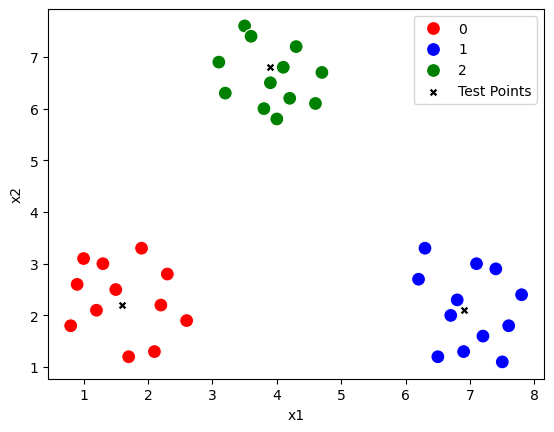

In [40]:
#visualization

sns.scatterplot(
    data = X_train_df,
    x = "x1",
    y = "x2",
    palette=["red", "blue", "green"],
    s=100,
    hue = "label"
)

sns.scatterplot(
    data = X_test_df,
    x = "x1",
    y = "x2",
    marker = "X",
    color = "Black",
    label = "Test Points"
)
    